# Training GPT — Slow and Steady

Let's try training with a very conservative learning rate. Better safe than sorry, right?

In [1]:
import sys
sys.path.insert(0, '..')

import torch
import tiktoken
import math
from minigpt.model import GPTModel
from minigpt.data import create_dataloaders
from minigpt.generate import generate

## 1. Load Data

In [2]:
import urllib.request
import os

data_dir = '../data'
os.makedirs(data_dir, exist_ok=True)
filepath = os.path.join(data_dir, 'tinyshakespeare.txt')

if not os.path.exists(filepath):
    url = 'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'
    urllib.request.urlretrieve(url, filepath)

with open(filepath, 'r') as f:
    text = f.read()

print(f'Dataset size: {len(text):,} characters')

Dataset size: 1,115,394 characters


## 2. Model + DataLoaders

In [15]:
SMALL_CONFIG = {
    'vocab_size': 50257,
    'context_length': 256,
    'emb_dim': 128,
    'n_heads': 4,
    'n_layers': 4,
    'drop_rate': 0.1,
    'qkv_bias': False,
}

tokenizer = tiktoken.get_encoding('gpt2')

train_loader, val_loader = create_dataloaders(
    text,
    tokenizer,
    max_length=SMALL_CONFIG['context_length'],
    stride=SMALL_CONFIG['context_length'],
    batch_size=8,
    train_ratio=0.9,
)

device = torch.device('mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

model = GPTModel(SMALL_CONFIG).to(device)
print(f'Model parameters: {sum(p.numel() for p in model.parameters()):,}')

Using device: mps
Model parameters: 7,257,472


## 3. Training

Using a tiny learning rate so we don't overshoot. We learned that high LR can cause problems, so let's go very small.

In [16]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-7)

NUM_EPOCHS = 10

train_losses = []
val_losses = []
step_losses = []

for epoch in range(NUM_EPOCHS):
    model.train()
    epoch_loss = 0.0
    num_batches = 0

    for input_ids, target_ids in train_loader:
        input_ids = input_ids.to(device)
        target_ids = target_ids.to(device)

        logits = model(input_ids)
        loss = torch.nn.functional.cross_entropy(
            logits.view(-1, logits.size(-1)),
            target_ids.view(-1)
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        num_batches += 1
        step_losses.append(loss.item())

    avg_train_loss = epoch_loss / num_batches
    train_losses.append(avg_train_loss)

    model.eval()
    val_loss = 0.0
    val_batches = 0
    with torch.no_grad():
        for input_ids, target_ids in val_loader:
            input_ids = input_ids.to(device)
            target_ids = target_ids.to(device)
            logits = model(input_ids)
            loss = torch.nn.functional.cross_entropy(
                logits.view(-1, logits.size(-1)),
                target_ids.view(-1)
            )
            val_loss += loss.item()
            val_batches += 1

    avg_val_loss = val_loss / val_batches
    val_losses.append(avg_val_loss)

    print(f'Epoch {epoch+1}/{NUM_EPOCHS} — Train: {avg_train_loss:.4f}, Val: {avg_val_loss:.4f}, PPL: {math.exp(avg_val_loss):.1f}')

Epoch 1/10 — Train: 77.8304, Val: 81.0522, PPL: 158673989597046291924400965247041536.0
Epoch 2/10 — Train: 77.7856, Val: 80.9818, PPL: 147898869647011040115944228483235840.0
Epoch 3/10 — Train: 77.7197, Val: 80.9108, PPL: 137759979544791521688842103628496896.0
Epoch 4/10 — Train: 77.6275, Val: 80.8392, PPL: 128240535833729035578092270502543360.0
Epoch 5/10 — Train: 77.6044, Val: 80.7669, PPL: 119293374950392847501020015229927424.0
Epoch 6/10 — Train: 77.5391, Val: 80.6939, PPL: 110898927036111563146083468973178880.0
Epoch 7/10 — Train: 77.4535, Val: 80.6202, PPL: 103012969220346153930457800360591360.0
Epoch 8/10 — Train: 77.4047, Val: 80.5457, PPL: 95625424799082944703968914354208768.0
Epoch 9/10 — Train: 77.3371, Val: 80.4707, PPL: 88714189800936672069557982001627136.0
Epoch 10/10 — Train: 77.2543, Val: 80.3951, PPL: 82249964732367043649013446529253376.0


## 4. Loss Curves

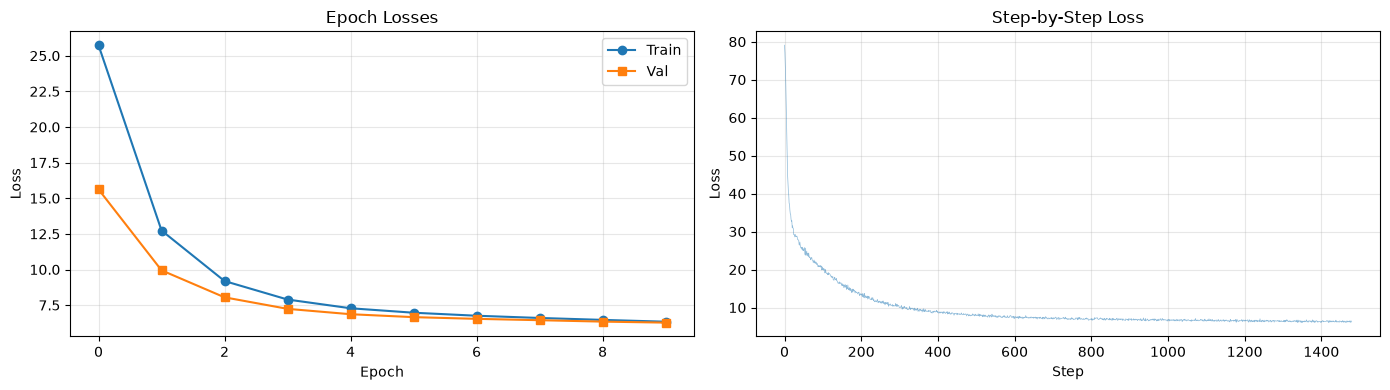


First epoch loss:  25.7373
Last epoch loss:   6.3378
Total improvement: 19.399523


In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(train_losses, label='Train', marker='o')
axes[0].plot(val_losses, label='Val', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Epoch Losses')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(step_losses, alpha=0.5, linewidth=0.5)
axes[1].set_xlabel('Step')
axes[1].set_ylabel('Loss')
axes[1].set_title('Step-by-Step Loss')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\nFirst epoch loss:  {train_losses[0]:.4f}')
print(f'Last epoch loss:   {train_losses[-1]:.4f}')
print(f'Total improvement: {train_losses[0] - train_losses[-1]:.6f}')

## 5. Generate Text

In [ ]:
model.eval()

prompt = 'ROMEO:'
input_ids = torch.tensor([tokenizer.encode(prompt)]).to(device)

with torch.no_grad():
    output_ids = generate(model, input_ids, max_new_tokens=100, context_length=SMALL_CONFIG['context_length'])

generated_text = tokenizer.decode(output_ids[0].tolist())
print(f'Generated:\n{generated_text}')

## 6. Sanity Check — What Should Loss Be?

A random model over 50,257 tokens should have loss = ln(50257) ≈ 10.82. After 10 epochs, where is ours?

In [ ]:
import math
random_loss = math.log(50257)
print(f'Random model loss: {random_loss:.4f}')
print(f'Our final loss:    {train_losses[-1]:.4f}')
print(f'Difference:        {random_loss - train_losses[-1]:.6f}')